In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math


# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
filter_length = 2.0*snap['0_Diameters']


Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [2]:
sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
                        search_radius=filter_length.value)

In [3]:
sf_small = tc.SmoothingFilter(snap, center, np.array([5e2, 5e2, 5e2], dtype=float), npix=64, orientation=None, 
                        search_radius=filter_length.value)

In [4]:
sf_spherical = tc.SmoothingFilter(snap, center, widths, npix=16, orientation=None, 
                        search_radius=filter_length.value, tilingType='spherical', rMin=0.0, rMax=8e2)

In [5]:
sf_spherical_powerlaw = tc.SmoothingFilter(snap, center, widths, npix=16, orientation=None, 
                        search_radius=filter_length.value, tilingType='spherical', rMin=0.0, rMax=8e2, 
                                  typeGrid='power-law', powerGrid=2)

In [6]:

filt_density = sf.filter_variable('0_Density',filter_length, 
                                  weight='0_Volume', filter_type="gaussian")

In [7]:

filt_density_small = sf_small.filter_variable('0_Density',filter_length, 
                                              weight='0_Volume', filter_type="gaussian")

In [8]:
filt_density_spherical = sf_spherical.filter_variable('0_Density',filter_length,
                                                      weight='0_Volume', filter_type="gaussian")

In [9]:
filt_density_spherical_powerlaw = sf_spherical_powerlaw.filter_variable('0_Density',filter_length,
                                                      weight='0_Volume', filter_type="gaussian")

In [10]:
mask_cartesian = np.zeros(snap['0_Density'].shape,dtype='int')
mask_cartesian[sf.index] = sf.isParticleInDomainUnSorted.get()

mask_small = np.zeros(snap['0_Density'].shape,dtype='int')
mask_small[sf_small.index] = sf_small.isParticleInDomainUnSorted.get()

mask_spherical = np.zeros(snap['0_Density'].shape,dtype='int')
mask_spherical[sf_spherical.index] = sf_spherical.isParticleInDomainUnSorted.get()

mask_spherical_powerlaw = np.zeros(snap['0_Density'].shape,dtype='int')
mask_spherical_powerlaw[sf_spherical_powerlaw.index] = sf_spherical_powerlaw.isParticleInDomainUnSorted.get()

In [11]:
snap['0_smooth_var_default'] = snap['0_Density'].copy
snap['0_smooth_var_default'][mask_cartesian>0] = filt_density[sf.isParticleInDomainUnSorted.get()>0]

snap['0_smooth_var_small'] = snap['0_Density'].copy
snap['0_smooth_var_small'][mask_small>0] = filt_density_small[sf_small.isParticleInDomainUnSorted.get()>0]

snap['0_smooth_var_spherical'] = snap['0_Density'].copy
snap['0_smooth_var_spherical'][mask_spherical>0] = filt_density_spherical[sf_spherical.isParticleInDomainUnSorted.get()>0]

snap['0_smooth_var_spherical_powerlaw'] = snap['0_Density'].copy
snap['0_smooth_var_spherical_powerlaw'][mask_spherical_powerlaw>0] = filt_density_spherical_powerlaw[sf_spherical_powerlaw.isParticleInDomainUnSorted.get()>0]

In [12]:
mask_tot_small = mask_cartesian*mask_small
mask_tot_inter = mask_cartesian*mask_spherical
mask_tot_spherical_log_powerlaw = mask_spherical*mask_spherical_powerlaw

In [13]:
np.allclose(snap['0_smooth_var_default'][np.argwhere(mask_tot_small>0)].value, 
            snap['0_smooth_var_small'][np.argwhere(mask_tot_small>0)].value, 
            rtol=1e-12, atol=1e-8)

True

In [14]:
np.allclose(snap['0_smooth_var_default'][np.argwhere(mask_tot_inter>0)].value, 
            snap['0_smooth_var_spherical'][np.argwhere(mask_tot_inter>0)].value, 
            rtol=1e-12, atol=1e-8)

True

In [15]:
np.allclose(snap['0_smooth_var_spherical_powerlaw'][np.argwhere(mask_tot_spherical_log_powerlaw>0)].value, 
            snap['0_smooth_var_spherical'][np.argwhere(mask_tot_spherical_log_powerlaw>0)].value, 
            rtol=1e-12, atol=1e-8)

True

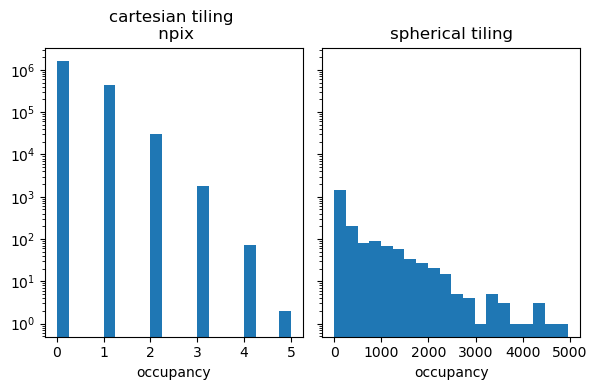

min/max occupancy cartesian tiling 0 / 5
min/max occupancy spherical tiling 0 / 4965


In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(cp.asnumpy(sf.tile.particles_per_tile).flatten(), bins=n_bins)
axs[1].hist(cp.asnumpy(sf_spherical.tile.particles_per_tile).flatten(), bins=n_bins)

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling \n npix')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('occupancy')
axs[1].set_xlabel('occupancy')

plt.show()

print("min/max occupancy cartesian tiling %d / %d"%(sf.tile.particles_per_tile.min(),sf.tile.particles_per_tile.max()))
print("min/max occupancy spherical tiling %d / %d"%(sf_spherical.tile.particles_per_tile.min(),sf_spherical.tile.particles_per_tile.max()))

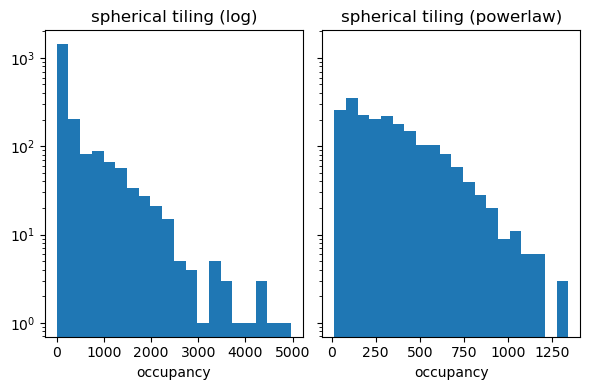

min/max occupancy spherical log tiling 0 / 4965
min/max occupancy spherical powerlaw tiling 14 / 1343


In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(cp.asnumpy(sf_spherical.tile.particles_per_tile).flatten(), bins=n_bins)
axs[1].hist(cp.asnumpy(sf_spherical_powerlaw.tile.particles_per_tile).flatten(), bins=n_bins)

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('spherical tiling (log)')
axs[1].set_title('spherical tiling (powerlaw)')

axs[0].set_xlabel('occupancy')
axs[1].set_xlabel('occupancy')

plt.show()

print("min/max occupancy spherical log tiling %d / %d"%(sf_spherical.tile.particles_per_tile.min(),
                                                        sf_spherical.tile.particles_per_tile.max()))
print("min/max occupancy spherical powerlaw tiling %d / %d"%(sf_spherical_powerlaw.tile.particles_per_tile.min(),
                                                             sf_spherical_powerlaw.tile.particles_per_tile.max()))

Text(0.5, 0.95, 'Tile occupancy spherical grid n=016')

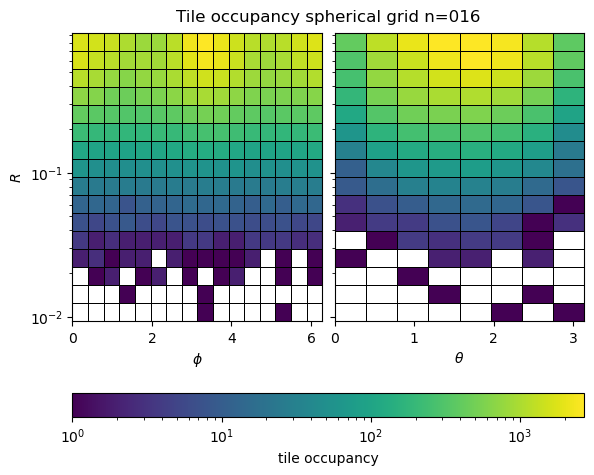

In [18]:
rMin = sf_spherical.tile._rMin*1e-3
rMax = sf_spherical.tile._rMax*1e-3
theta_min = 0.0
theta_max = np.pi
phi_min = 0.0
phi_max = 2*np.pi

nSectRad = int(sf_spherical.tile.nSects[0])
nSectPhi = int(sf_spherical.tile.nSects[1])
nSectThe = int(sf_spherical.tile.nSects[2])

radialgrid = np.logspace(np.log10(rMin),np.log10(rMax),nSectRad+1)
azigrid = np.linspace(phi_min, phi_max, nSectPhi+1)
latgrid = np.linspace(theta_min, theta_max, nSectThe+1)

spherical_occupancy = cp.asnumpy(sf_spherical.tile.particles_per_tile)

fig, ax = plt.subplots(1,2, sharey=True)

im = ax[0].pcolormesh(azigrid, radialgrid, spherical_occupancy[:,:,nSectThe//2],  
                      norm=LogNorm(),shading='flat', edgecolors='k', linewidths=0.4)

im = ax[1].pcolormesh(latgrid, radialgrid, spherical_occupancy[:,0,:], 
                      norm=LogNorm(), shading='flat', edgecolors='k', linewidths=0.4)

ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$\phi$')
ax[0].set_ylabel(r'$R$')

ax[1].set_xlabel(r'$\theta$')

cbar_ax = fig.add_axes([0.1, 0.1, 0.8, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('tile occupancy')

fig.subplots_adjust(top=0.9,
bottom=0.3,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Tile occupancy spherical grid n=%03d'%(nSectRad),y=0.95)

Text(0.5, 0.95, 'Tile occupancy cartesian grid n=128')

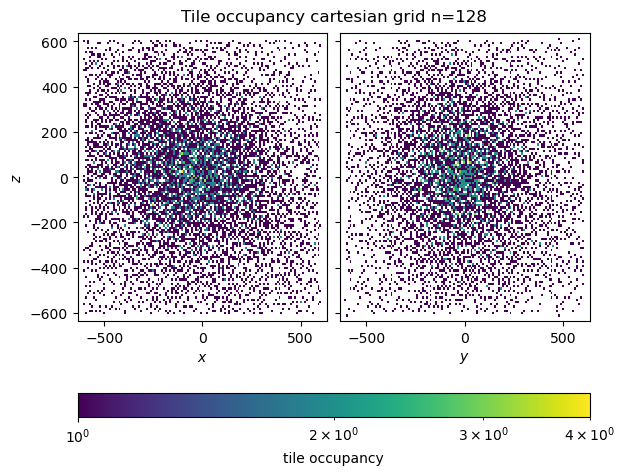

In [19]:
xmin = float(-sf.tile.tilebox_widths[0]/2.0)
xmax = float( sf.tile.tilebox_widths[0]/2.0)
ymin = float(-sf.tile.tilebox_widths[1]/2.0)
ymax = float( sf.tile.tilebox_widths[1]/2.0)
zmin = float(-sf.tile.tilebox_widths[2]/2.0)
zmax = float( sf.tile.tilebox_widths[2]/2.0)

npix_x, npix_y, npix_z = sf.tile.npixs
npix_x = int(npix_x)
npix_y = int(npix_y)
npix_z = int(npix_z)

xgrid = np.linspace(xmin, xmax, npix_x+1)
ygrid = np.linspace(ymin, ymax, npix_y+1)
zgrid = np.linspace(zmin, zmax, npix_z+1)

cartesian_occupancy = cp.asnumpy(sf.tile.particles_per_tile)

fig, ax = plt.subplots(1,2, sharey=True)

im = ax[0].pcolormesh(xgrid, zgrid, cartesian_occupancy[:,npix_y//2,:].T,  norm=LogNorm())

im = ax[1].pcolormesh(ygrid, zgrid, cartesian_occupancy[npix_x//2,:,:].T, norm=LogNorm())

# ax[0].set_yscale('log')
# ax[1].set_yscale('log')

ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$z$')

ax[1].set_xlabel(r'$y$')

cbar_ax = fig.add_axes([0.1, 0.1, 0.8, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('tile occupancy')

fig.subplots_adjust(top=0.9,
bottom=0.3,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Tile occupancy cartesian grid n=%03d'%(npix_x),y=0.95)

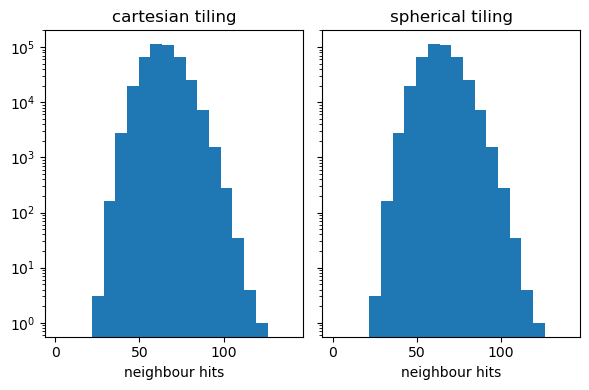

min/max hits cartesian tiling 27 / 121
min/max hits spherical tiling 27 / 121


In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

# this brings back the intersection region into the respective
# cartesian/spherical selection with appropriate sorting
masktot2spherical_srt = mask_tot_inter[sf_spherical.index][sf_spherical.tile.sort_index.get()]
masktot2cartesian_srt = mask_tot_inter[sf.index][sf.tile.sort_index.get()]

hitsNeighbours_cartesian_common = cp.asnumpy(sf.hitsNeighbours)[np.argwhere(masktot2cartesian_srt>0)]
hitsNeighbours_spherical_common = cp.asnumpy(sf_spherical.hitsNeighbours)[np.argwhere(masktot2spherical_srt>0)]

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(hitsNeighbours_cartesian_common, bins=n_bins, range=[1,140])
axs[1].hist(hitsNeighbours_spherical_common, bins=n_bins,range=[1,140])

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('neighbour hits')
axs[1].set_xlabel('neighbour hits')

plt.show()

print("min/max hits cartesian tiling %d / %d"%(hitsNeighbours_cartesian_common.min(),hitsNeighbours_cartesian_common.max()))
print("min/max hits spherical tiling %d / %d"%(hitsNeighbours_spherical_common.min(),hitsNeighbours_spherical_common.max()))